# Welfare State as Recovery-Rate Governor: Four-Step Empirical Pipeline

This notebook demonstrates the full four-step empirical pipeline testing the 'Welfare State as Recovery-Rate Governor' hypothesis:

- **Step 0 (MC Validation):** Monte Carlo simulation to select the least-biased AR(1) estimator
- **Step 1 (Recovery Rates):** Per-country bias-corrected AR(1) recovery-rate panel via rolling 20-year windows over HP-detrended V-Dem electoral democracy residuals
- **Step 2 (CSD Anticipation):** Test for Critical Slowing Down (rising AC1, variance) in the 5-year pre-onset window before gradual democratic erosion events
- **Step 3 (Rate Regression):** Panel OLS regressing recovery rate on 5-year lagged redistribution (OECD: gini_market − gini_disposable), with controls
- **Step 4 (Hazard Model):** Discrete-time hazard logit with inequality × redistribution interaction

**Data:** Mini demo subset of 7 countries (1989–2023) embedded in `mini_demo_data.json`.
Full-run data sources: V-Dem electoral democracy (OWID), Penn World Table, OECD Income Distribution Database.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# psutil, loguru — NOT pre-installed on Colab
_pip('psutil', 'loguru')

# Core packages — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1',
         'statsmodels==0.14.6', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import json
import math
import os
import sys
import time

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from loguru import logger
from scipy.optimize import minimize_scalar
from scipy.stats import kendalltau, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ── Logging setup ─────────────────────────────────────────────────────────────
GREEN, CYAN, END = "\033[92m", "\033[96m", "\033[0m"
logger.remove()
logger.add(
    sys.stdout,
    level="INFO",
    format=f"{GREEN}{{time:HH:mm:ss}}{END}|{{level:<7}}|{CYAN}{{function}}{END}| {{message}}",
)

# ── Estimators (from estimators.py) ──────────────────────────────────────────
def ols_ar1(y: np.ndarray) -> float:
    """OLS AR(1) estimator — downward biased for short T."""
    y = y - y.mean()
    denom = np.dot(y[:-1], y[:-1])
    if denom < 1e-12:
        return 0.0
    return float(np.clip(np.dot(y[1:], y[:-1]) / denom, -0.999, 0.999))

def andrews_mu_ar1(y: np.ndarray) -> float:
    """Andrews (1993) / Roy-Fuller median-unbiased AR(1) estimator."""
    T = len(y)
    phi_ols = ols_ar1(y)
    if T <= 4:
        return phi_ols
    df = float(T - 2)
    denom = 1.0 - 3.0 / df
    if abs(denom) < 1e-6:
        return phi_ols
    phi_mu = (phi_ols + 1.0 / df) / denom
    denom2 = 1.0 - 3.0 / df
    if abs(denom2) > 1e-6:
        phi_mu = (phi_ols + 1.0 / df) / denom2
    return float(np.clip(phi_mu, -0.999, 0.999))

def kilian_bab_ar1(y: np.ndarray, B1: int = 499, B2: int = 199, seed: int = 42) -> float:
    """Kilian (1998) bootstrap-after-bootstrap bias-corrected AR(1) estimator."""
    rng = np.random.default_rng(seed)
    T = len(y)
    y = y - y.mean()
    phi_ols = ols_ar1(y)
    resid = y[1:] - phi_ols * y[:-1]
    resid_c = resid - resid.mean()

    def _bootstrap_phi(phi_src: float, B: int) -> list:
        out = []
        for _ in range(B):
            boot = rng.choice(resid_c, size=T - 1, replace=True)
            yb = np.zeros(T)
            yb[0] = y[0]
            for t in range(1, T):
                yb[t] = phi_src * yb[t - 1] + boot[t - 1]
            out.append(ols_ar1(yb))
        return out

    phi_b1 = _bootstrap_phi(phi_ols, B1)
    bias1 = float(np.mean(phi_b1)) - phi_ols
    phi_bc = float(np.clip(phi_ols - bias1, -0.999, 0.999))
    phi_b2 = _bootstrap_phi(phi_bc, B2)
    bias2 = float(np.mean(phi_b2)) - phi_bc
    phi_bab = float(np.clip(phi_bc - bias2, -0.999, 0.999))
    return phi_bab

def ou_mle_ar1(y: np.ndarray, dt: float = 1.0):
    """Ornstein-Uhlenbeck exact-likelihood MLE for AR(1). Returns (phi, lambda)."""
    y = y - y.mean()

    def neg_ll(phi: float) -> float:
        if phi <= 1e-6 or phi >= 1.0:
            return 1e10
        resid = y[1:] - phi * y[:-1]
        sigma2 = float(np.var(resid))
        if sigma2 <= 0:
            return 1e10
        T = len(y)
        return 0.5 * (T - 1) * np.log(sigma2) + 0.5 * np.sum(resid ** 2) / sigma2

    result = minimize_scalar(neg_ll, bounds=(0.01, 0.999), method="bounded")
    phi_mle = float(result.x)
    lambda_hat = -np.log(phi_mle) / dt
    return phi_mle, lambda_hat

# ── HP detrending utility (from utils.py) ─────────────────────────────────────
def detrend_hp(edi: np.ndarray, lamb: float = 6.25):
    """Hodrick-Prescott filter (Ravn-Uhlig: lambda=6.25 for annual)."""
    from statsmodels.tsa.filters.hp_filter import hpfilter
    if len(edi) < 8:
        trend = np.full_like(edi, np.mean(edi))
        return edi - trend, trend
    cycle, trend = hpfilter(edi, lamb=lamb)
    return np.asarray(cycle), np.asarray(trend)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-a5d3bf-the-welfare-state-as-a-recovery-rate-gov/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

data = load_data()
logger.info(f"Loaded data: {len(data['vdem_panel'])} vdem rows, {len(data['redistrib_df'])} redistrib rows")

03:34:29|INFO   |<module>| Loaded data: 245 vdem rows, 42 redistrib rows


## Configuration

All tunable parameters are defined here. Set to **minimum values** for a fast demo run.
To reproduce the full original experiment, use the commented-out values.

In [4]:
# ── Step 0: Monte Carlo config ────────────────────────────────────────────────
N_SIM = 200           # original: 2000
PHI_GRID = [0.70, 0.80, 0.90, 0.95, 0.99]   # original: same
T_GRID = [20]         # original: [15, 20, 25]
SEED = 42

# ── Step 1: Recovery rates config ─────────────────────────────────────────────
WINDOW = 20           # original: 20 (rolling AR(1) window in years)
STEP = 1              # original: 1 (slide by 1 year)
NUM_WORKERS = 1       # original: up to 5 (use 1 for notebook compatibility)

# ── Step 2: CSD anticipation config ───────────────────────────────────────────
PRE_WINDOW = 5        # original: 5 (years before onset to check for CSD)

## Data Preparation

Reconstruct pandas DataFrames from the loaded JSON. The mini dataset contains:
- **`vdem_panel`**: 7 countries × 35 years (1989–2023) of Electoral Democracy Index (EDI)
- **`redistrib_df`**: Redistribution = gini_market − gini_disposable at survey years (every 5 years)
- **`gdp_panel`**: Log GDP per capita
- **`schooling_panel`**: Human capital index (schooling proxy)

Democratic backsliding onsets are derived algorithmically from the EDI panel (cumulative drop > 0.05 over 3+ years).

In [5]:
# ── Build DataFrames from loaded data ─────────────────────────────────────────
vdem_panel = pd.DataFrame(data['vdem_panel'])
redistrib_df = pd.DataFrame(data['redistrib_df'])
gdp_panel = pd.DataFrame(data['gdp_panel'])
schooling_panel = pd.DataFrame(data['schooling_panel'])

logger.info(f"V-Dem: {vdem_panel['country'].nunique()} countries, "
            f"{int(vdem_panel['year'].min())}-{int(vdem_panel['year'].max())}")
logger.info(f"Redistribution: {len(redistrib_df)} rows, {redistrib_df['country'].nunique()} countries")

# ── Derive onsets algorithmically from V-Dem EDI decline ─────────────────────
# (mirrors data_loader.py:derive_onsets_from_vdem)
def derive_onsets_from_vdem(vdem_panel: pd.DataFrame) -> pd.DataFrame:
    """Derive backsliding onsets from sustained EDI decline > 0.05 over 3+ years."""
    records = []
    for country, grp in vdem_panel.groupby("country"):
        grp = grp.sort_values("year").reset_index(drop=True)
        if len(grp) < 6 or "edi" not in grp.columns:
            continue
        edi = grp["edi"].values
        years = grp["year"].values
        for i in range(2, len(edi) - 1):
            window = edi[max(0, i - 3): i + 1]
            if len(window) < 3:
                continue
            cum_drop = window[0] - window[-1]
            rate = cum_drop / len(window)
            if cum_drop > 0.05:
                ep_type = "gradual" if rate < 0.03 else "coup_like"
                records.append({
                    "country_name": country, "country": country,
                    "year": int(years[i]), "ep_type": ep_type, "derived": True,
                })
    df = pd.DataFrame(records)
    if len(df):
        df = df.sort_values("year").groupby("country").first().reset_index()
    logger.info(f"Derived {len(df)} onsets algorithmically from V-Dem")
    return df

onset_df = derive_onsets_from_vdem(vdem_panel)
print(onset_df[['country', 'year', 'ep_type']].to_string(index=False))

03:34:29|INFO   |<module>| V-Dem: 7 countries, 1989-2023


03:34:29|INFO   |<module>| Redistribution: 42 rows, 7 countries


03:34:29|INFO   |derive_onsets_from_vdem| Derived 5 onsets algorithmically from V-Dem


country  year ep_type
 Brazil  2013 gradual
Hungary  2012 gradual
  India  2015 gradual
 Poland  2017 gradual
 Turkey  2011 gradual


## Step 0: Monte Carlo Validation of AR(1) Estimators

Before estimating recovery rates, we need to know which AR(1) estimator has the lowest bias at high persistence (φ near 1). Four estimators are compared:
- **OLS**: standard regression — known to be downward biased for short T and high φ
- **Andrews MU**: median-unbiased bias correction using Roy-Fuller denominator
- **Kilian BAB**: bootstrap-after-bootstrap bias correction (expensive but accurate)
- **OU MLE**: exact Ornstein-Uhlenbeck likelihood

The estimator with the lowest max|bias| at key persistence values (φ ∈ {0.90, 0.95}) is recommended for Step 1.

In [6]:
# ── Step 0: Monte Carlo (from step0_montecarlo.py) ────────────────────────────
# Run sequentially (NUM_WORKERS=1) to avoid notebook multiprocessing issues

def _run_cell(args: tuple) -> dict:
    phi_true, T, n_sim, seed = args
    rng = np.random.default_rng(seed)
    sigma = np.sqrt(max(1 - phi_true ** 2, 1e-6))
    phi_ols_list, phi_mu_list, phi_mle_list = [], [], []
    for _ in range(n_sim):
        eps = rng.normal(0, sigma, T)
        y = np.zeros(T)
        for t in range(1, T):
            y[t] = phi_true * y[t - 1] + eps[t]
        y = y - y.mean()
        phi_ols_list.append(ols_ar1(y))
        phi_mu_list.append(andrews_mu_ar1(y))
        phi_mle_list.append(ou_mle_ar1(y)[0])

    results = []
    for name, lst in [("OLS", phi_ols_list), ("Andrews_MU", phi_mu_list), ("OU_MLE", phi_mle_list)]:
        arr = np.array(lst)
        bias = float(np.mean(arr) - phi_true)
        rmse = float(np.sqrt(np.mean((arr - phi_true) ** 2)))
        ci_width = float(np.percentile(arr, 97.5) - np.percentile(arr, 2.5))
        results.append({
            "phi_true": phi_true, "T": T, "estimator": name,
            "bias": round(bias, 5), "rmse": round(rmse, 5),
            "ci_width_95": round(ci_width, 5),
            "mean_est": round(float(np.mean(arr)), 5),
        })

    # Kilian BAB with reduced reps (expensive)
    rng2 = np.random.default_rng(seed + 1)
    phi_kil_list = []
    n_kil = min(n_sim, 200)
    sigma2 = np.sqrt(max(1 - phi_true ** 2, 1e-6))
    for _ in range(n_kil):
        eps = rng2.normal(0, sigma2, T)
        y = np.zeros(T)
        for t in range(1, T):
            y[t] = phi_true * y[t - 1] + eps[t]
        y = y - y.mean()
        phi_kil_list.append(kilian_bab_ar1(y, B1=99, B2=49, seed=int(rng2.integers(0, 9999))))
    arr_k = np.array(phi_kil_list)
    bias_k = float(np.mean(arr_k) - phi_true)
    rmse_k = float(np.sqrt(np.mean((arr_k - phi_true) ** 2)))
    ci_k = float(np.percentile(arr_k, 97.5) - np.percentile(arr_k, 2.5))
    results.append({
        "phi_true": phi_true, "T": T, "estimator": "Kilian_BAB",
        "bias": round(bias_k, 5), "rmse": round(rmse_k, 5),
        "ci_width_95": round(ci_k, 5),
        "mean_est": round(float(np.mean(arr_k)), 5),
        "n_sim_kilian": n_kil,
    })
    return {"phi_true": phi_true, "T": T, "results": results}


def run_step0(n_sim: int = N_SIM, num_workers: int = NUM_WORKERS) -> dict:
    logger.info(f"Step 0: Monte Carlo with N_SIM={n_sim}, workers={num_workers}")
    cells = [(phi, T, n_sim, SEED + i * 100) for i, (phi, T) in enumerate(
        [(phi, T) for phi in PHI_GRID for T in T_GRID]
    )]

    all_results = []
    # Sequential execution for notebook compatibility (NUM_WORKERS=1)
    for c in cells:
        cell_out = _run_cell(c)
        all_results.extend(cell_out["results"])
        logger.info(f"  MC cell done: phi={cell_out['phi_true']}, T={cell_out['T']}")

    # Select recommended estimator: lowest |bias| at key phis, T=20
    key_phis = set(PHI_GRID[1:])  # exclude lowest phi
    est_bias: dict = {}
    for r in all_results:
        if r["phi_true"] in key_phis and r["T"] == 20:
            est_bias.setdefault(r["estimator"], []).append(abs(r["bias"]))
    est_max_bias = {e: max(v) for e, v in est_bias.items()}
    recommended = min(est_max_bias, key=lambda e: est_max_bias[e]) if est_max_bias else "Andrews_MU"
    bias_ok = est_max_bias.get(recommended, 1.0) < 0.05

    _rec_bias = est_max_bias.get(recommended)
    output = {
        "results": all_results,
        "recommended_estimator": recommended,
        "bias_ok": bias_ok,
        "estimator_max_bias_at_key_phis": {e: round(v, 4) for e, v in est_max_bias.items()},
        "notes": f"Recommended estimator: {recommended} (max|bias|={_rec_bias:.3f})" if _rec_bias else recommended,
    }
    logger.info(f"Step 0 complete. Recommended: {recommended}, bias_ok={bias_ok}")
    return output


t0 = time.time()
step0 = run_step0(n_sim=N_SIM, num_workers=NUM_WORKERS)
estimator_used = step0.get("recommended_estimator", "Andrews_MU")
logger.info(f"Step 0 done in {time.time()-t0:.1f}s. Recommended estimator: {estimator_used}")

03:34:29|INFO   |run_step0| Step 0: Monte Carlo with N_SIM=200, workers=1


03:34:32|INFO   |run_step0|   MC cell done: phi=0.7, T=20


03:34:35|INFO   |run_step0|   MC cell done: phi=0.8, T=20


03:34:38|INFO   |run_step0|   MC cell done: phi=0.9, T=20


03:34:42|INFO   |run_step0|   MC cell done: phi=0.95, T=20


03:34:44|INFO   |run_step0|   MC cell done: phi=0.99, T=20


03:34:44|INFO   |run_step0| Step 0 complete. Recommended: Kilian_BAB, bias_ok=False


03:34:44|INFO   |<module>| Step 0 done in 15.5s. Recommended estimator: Kilian_BAB


## Step 1: Per-Country Bias-Corrected Recovery-Rate Panel

For each country, a rolling 20-year window slides across the HP-detrended EDI series. Within each window, the selected bias-corrected AR(1) estimator fits φ (persistence), and the recovery rate is λ = −log(φ).

A higher λ means faster recovery from democratic shocks (more resilient democracy). A lower λ (φ near 1) means the system is close to a tipping point — the core Critical Slowing Down signal.

In [7]:
# ── Step 1: Rolling recovery rates (from step1_recovery_rates.py) ─────────────

def _rolling_recovery_country(args: tuple) -> list:
    country, years, edi, estimator_name, window, n_boot = args
    try:
        if len(edi) < window + 3:
            return []
        try:
            resid, trend = detrend_hp(edi)
        except Exception:
            resid = edi - np.mean(edi)

        results = []
        for i in range(0, len(resid) - window + 1, STEP):
            win = resid[i: i + window]
            if np.std(win) < 1e-6:
                continue
            if estimator_name == "Andrews_MU":
                phi_est = andrews_mu_ar1(win)
            elif estimator_name == "OU_MLE":
                phi_est, _ = ou_mle_ar1(win)
            else:
                phi_est = ols_ar1(win)

            phi_est = float(np.clip(phi_est, 0.01, 0.999))
            lambda_est = -np.log(phi_est)
            center_year = int(years[i + window // 2])

            ac1 = float(np.corrcoef(win[:-1], win[1:])[0, 1]) if np.std(win) > 0 else 0.0
            var = float(np.var(win))

            # Delta-method CI for lambda
            se_phi = (1.0 - phi_est ** 2) / np.sqrt(window)
            se_lambda = se_phi / phi_est
            lambda_lo = max(0.0, lambda_est - 1.96 * se_lambda)
            lambda_hi = lambda_est + 1.96 * se_lambda

            results.append({
                "country": country, "center_year": center_year,
                "phi_bc": round(phi_est, 5), "lambda_bc": round(lambda_est, 5),
                "lambda_lo": round(lambda_lo, 5), "lambda_hi": round(lambda_hi, 5),
                "ac1_rolling": round(ac1, 5), "var_rolling": round(var, 8),
                "n_obs_window": window,
            })
        return results
    except Exception as e:
        logger.error(f"Country {country} failed: {e}")
        return []


def run_step1(vdem_panel: pd.DataFrame, estimator_name: str = "Andrews_MU",
              num_workers: int = NUM_WORKERS) -> dict:
    logger.info(f"Step 1: Rolling recovery rates, estimator={estimator_name}, window={WINDOW}")

    countries = vdem_panel["country"].unique()
    tasks = []
    for country in countries:
        grp = vdem_panel[vdem_panel["country"] == country].sort_values("year")
        years = grp["year"].values.astype(float)
        edi = grp["edi"].values.astype(float)
        if len(edi) < WINDOW + 3:
            continue
        tasks.append((country, years, edi, estimator_name, WINDOW, 100))

    logger.info(f"Processing {len(tasks)} countries")

    all_rows = []
    # Sequential execution (NUM_WORKERS=1)
    for t in tasks:
        rows = _rolling_recovery_country(t)
        all_rows.extend(rows)

    panel = pd.DataFrame(all_rows)
    if panel.empty:
        logger.warning("Step 1 produced no results!")
        return {"n_countries": 0, "n_country_years": 0, "panel": panel,
                "sample_rows": [], "signal_above_noise": False}

    n_countries = int(panel["country"].nunique())
    n_cy = len(panel)
    logger.info(f"Step 1 complete: {n_countries} countries, {n_cy} country-years")

    lam_std = float(panel["lambda_bc"].std())
    lam_mean = float(panel["lambda_bc"].mean())
    signal_ok = lam_std > 0.02 and lam_mean > 0.0

    return {
        "n_countries": n_countries, "n_country_years": n_cy,
        "panel": panel, "sample_rows": panel.head(5).to_dict("records"),
        "signal_above_noise": signal_ok,
        "lambda_mean": round(lam_mean, 4), "lambda_std": round(lam_std, 4),
    }


t1 = time.time()
step1 = run_step1(vdem_panel, estimator_name=estimator_used, num_workers=NUM_WORKERS)
recovery_panel = step1.pop("panel")
logger.info(f"Step 1 done in {time.time()-t1:.1f}s. {step1['n_country_years']} country-years")

03:34:44|INFO   |run_step1| Step 1: Rolling recovery rates, estimator=Kilian_BAB, window=20


03:34:44|INFO   |run_step1| Processing 7 countries


03:34:44|INFO   |run_step1| Step 1 complete: 7 countries, 112 country-years


03:34:44|INFO   |<module>| Step 1 done in 0.1s. 112 country-years


## Step 2: CSD Anticipation Test

Critical Slowing Down (CSD) theory predicts that a system approaching a tipping point exhibits rising autocorrelation (AC1) and variance. Here we test whether democracies that later experienced gradual erosion showed rising AC1 in the 5 years before onset (vs. a matched control group of non-onset countries).

**Prediction 1:** Mann-Whitney p < 0.10 and AUC > 0.55 for rising AC1 trend (Kendall-τ) in pre-onset windows.

In [8]:
# ── Step 2: CSD anticipation (from step2_csd_anticipation.py) ─────────────────

def _kendall_trend(series: np.ndarray) -> float:
    if len(series) < 3:
        return 0.0
    tau, _ = kendalltau(np.arange(len(series)), series)
    return float(tau) if not np.isnan(tau) else 0.0


def run_step2(recovery_panel: pd.DataFrame, onset_df: pd.DataFrame) -> dict:
    logger.info(f"Step 2: CSD anticipation test, {len(onset_df)} onsets")

    if onset_df.empty:
        return _step2_empty("No onset data")

    onset_df = onset_df.copy()
    col_map = {}
    for c in onset_df.columns:
        cl = c.lower()
        if "country" in cl:
            col_map[c] = "country"
        elif cl == "year":
            col_map[c] = "year"
        elif "ep_type" in cl or "type" in cl:
            col_map[c] = "ep_type"
    onset_df = onset_df.rename(columns=col_map)
    if "country" not in onset_df.columns and "country_name" in onset_df.columns:
        onset_df = onset_df.rename(columns={"country_name": "country"})
    onset_df = onset_df.loc[:, ~onset_df.columns.duplicated()]

    if "ep_type" in onset_df.columns:
        gradual_mask = onset_df["ep_type"].str.lower().str.contains("gradual", na=False)
        gradual_onsets = onset_df[gradual_mask].copy()
        coup_onsets = onset_df[~gradual_mask].copy()
    else:
        gradual_onsets = onset_df.copy()
        coup_onsets = pd.DataFrame()

    logger.info(f"Gradual onsets: {len(gradual_onsets)}, coup-like: {len(coup_onsets)}")

    cases_tau_ac1 = []
    cases_tau_var = []
    rp = recovery_panel.reset_index(drop=True)
    for _, row in gradual_onsets.iterrows():
        country = str(row["country"]) if "country" in row.index else str(row.get("country_name", ""))
        onset_year = int(row["year"])
        pre_start = onset_year - PRE_WINDOW
        mask = (
            (rp["country"] == country)
            & (rp["center_year"] >= pre_start)
            & (rp["center_year"] < onset_year)
        )
        pre_data = rp[mask].sort_values("center_year")
        if len(pre_data) < 3:
            continue
        cases_tau_ac1.append(_kendall_trend(pre_data["ac1_rolling"].values))
        cases_tau_var.append(_kendall_trend(pre_data["var_rolling"].values))

    all_countries = set(rp["country"].unique())
    onset_countries = set(gradual_onsets["country"].tolist())
    control_countries = list(all_countries - onset_countries)

    controls_tau_ac1 = []
    rng = np.random.default_rng(42)
    for _ in range(min(len(cases_tau_ac1) * 3, len(control_countries) * 3)):
        c = rng.choice(control_countries)
        grp = rp[rp["country"] == c].sort_values("center_year")
        if len(grp) < PRE_WINDOW:
            continue
        max_start = len(grp) - PRE_WINDOW
        start_i = int(rng.integers(0, max_start + 1))
        win = grp.iloc[start_i: start_i + PRE_WINDOW]
        controls_tau_ac1.append(_kendall_trend(win["ac1_rolling"].values))

    if len(cases_tau_ac1) < 3:
        return _step2_empty(f"Insufficient gradual onsets with recovery data: {len(cases_tau_ac1)}")

    try:
        mw_stat, p_mw = mannwhitneyu(cases_tau_ac1, controls_tau_ac1, alternative="greater")
    except Exception:
        p_mw = 1.0

    all_tau = cases_tau_ac1 + controls_tau_ac1
    all_labels = [1] * len(cases_tau_ac1) + [0] * len(controls_tau_ac1)
    try:
        from sklearn.metrics import roc_auc_score
        auc = float(roc_auc_score(all_labels, all_tau))
    except Exception:
        auc = 0.5

    # Reversed time placebo
    cases_tau_rev = []
    for _, row in gradual_onsets.iterrows():
        country = str(row["country"]) if "country" in row.index else str(row.get("country_name", ""))
        onset_year = int(row["year"])
        pre_start = onset_year - PRE_WINDOW
        mask = ((rp["country"] == country) & (rp["center_year"] >= pre_start) & (rp["center_year"] < onset_year))
        pre_data = rp[mask].sort_values("center_year")
        if len(pre_data) < 3:
            continue
        cases_tau_rev.append(_kendall_trend(pre_data["ac1_rolling"].values[::-1]))

    p_reversed = 1.0
    if cases_tau_rev and controls_tau_ac1:
        try:
            _, p_reversed = mannwhitneyu(cases_tau_rev, controls_tau_ac1, alternative="greater")
        except Exception:
            pass

    pred1_confirmed = bool(p_mw < 0.1 and auc > 0.55)

    output = {
        "n_gradual_onsets": len(gradual_onsets), "n_coup_onsets": len(coup_onsets),
        "n_cases_with_data": len(cases_tau_ac1), "n_controls": len(controls_tau_ac1),
        "mean_kendall_tau_ac1_cases": round(float(np.mean(cases_tau_ac1)), 4) if cases_tau_ac1 else None,
        "mean_kendall_tau_ac1_controls": round(float(np.mean(controls_tau_ac1)), 4) if controls_tau_ac1 else None,
        "p_wilcoxon": round(float(p_mw), 4), "auc": round(auc, 4),
        "p_reversed_time_placebo": round(float(p_reversed), 4),
        "prediction1_confirmed": pred1_confirmed,
    }
    logger.info(f"Step 2: p_mw={p_mw:.3f}, auc={auc:.3f}, pred1={pred1_confirmed}")
    return output


def _step2_empty(reason: str) -> dict:
    logger.warning(f"Step 2 empty: {reason}")
    return {
        "n_gradual_onsets": 0, "n_coup_onsets": 0, "n_cases_with_data": 0, "n_controls": 0,
        "mean_kendall_tau_ac1_cases": None, "mean_kendall_tau_ac1_controls": None,
        "p_wilcoxon": 1.0, "auc": 0.5, "p_reversed_time_placebo": 1.0,
        "prediction1_confirmed": False, "skip_reason": reason,
    }


step2 = run_step2(recovery_panel, onset_df)
logger.info(f"Step 2 done. pred1={step2.get('prediction1_confirmed')}")

03:34:44|INFO   |run_step2| Step 2: CSD anticipation test, 5 onsets


03:34:44|INFO   |run_step2| Gradual onsets: 5, coup-like: 0


03:34:45|INFO   |run_step2| Step 2: p_mw=0.069, auc=0.783, pred1=True


03:34:45|INFO   |<module>| Step 2 done. pred1=True


## Step 3: Panel Regression — Recovery Rate on Redistribution

The core welfare-governor test: regress the AR(1) recovery rate (λ) on 5-year lagged redistribution (gini_market − gini_disposable), controlling for GDP, human capital, region FE, and decade FE.

**Prediction 2:** Redistribution coefficient > 0 and p < 0.10 — higher redistribution → faster recovery from democratic shocks.

In [9]:
# ── Step 3: Rate regression (from step3_rate_regression.py) ──────────────────

def _safe_ols(formula: str, data: pd.DataFrame, cov_type: str = "HC3", cov_kwds=None):
    try:
        import statsmodels.formula.api as smf
        mod = smf.ols(formula, data=data)
        if cov_kwds:
            fit = mod.fit(cov_type=cov_type, cov_kwds=cov_kwds)
        else:
            fit = mod.fit(cov_type=cov_type)
        return fit
    except Exception as e:
        logger.error(f"OLS failed: {e} | formula: {formula[:100]}")
        return None


def _extract_coeff(fit, param_name: str) -> dict:
    if fit is None:
        return {"coeff": None, "se": None, "p": None}
    for name in fit.params.index:
        if param_name in name:
            return {
                "coeff": round(float(fit.params[name]), 5),
                "se": round(float(fit.bse[name]), 5),
                "p": round(float(fit.pvalues[name]), 4),
            }
    return {"coeff": None, "se": None, "p": None}


def _assign_regions(countries: np.ndarray) -> dict:
    western = {"United States", "Canada", "Australia", "Germany", "France", "Sweden",
               "United Kingdom", "Netherlands", "Belgium", "Austria", "Switzerland",
               "Norway", "Denmark", "Finland", "Ireland", "Greece", "Luxembourg"}
    eastern_europe = {"Poland", "Hungary", "Czech Republic", "Slovakia", "Romania",
                      "Bulgaria", "Croatia", "Slovenia", "Serbia", "Albania", "Lithuania",
                      "Latvia", "Estonia", "Moldova", "Ukraine", "Belarus"}
    latin_am = {"Brazil", "Argentina", "Chile", "Colombia", "Mexico", "Peru", "Venezuela"}
    africa = {"South Africa", "Nigeria", "Kenya", "Ethiopia", "Ghana", "Tanzania"}
    asia = {"India", "China", "Indonesia", "Pakistan", "Bangladesh", "Philippines",
            "Thailand", "Vietnam", "Malaysia"}
    mideast = {"Turkey", "Iran", "Iraq", "Saudi Arabia", "Israel", "Jordan"}

    region_map = {}
    for c in countries:
        if c in western: region_map[c] = "Western"
        elif c in eastern_europe: region_map[c] = "Eastern_Europe"
        elif c in latin_am: region_map[c] = "Latin_America"
        elif c in africa: region_map[c] = "Africa"
        elif c in asia: region_map[c] = "Asia"
        elif c in mideast: region_map[c] = "Middle_East"
        else: region_map[c] = "Other"
    return region_map


def run_step3(recovery_panel: pd.DataFrame, redistrib_df: pd.DataFrame,
              gdp_panel: pd.DataFrame, schooling_panel: pd.DataFrame) -> dict:
    logger.info("Step 3: Primary rate regression")

    if recovery_panel.empty:
        return _step3_empty("Empty recovery panel")

    redist = redistrib_df.copy()
    if redist.empty or "redistribution" not in redist.columns:
        logger.warning("No redistribution data; Step 3 will have limited variables")
        redist = pd.DataFrame(columns=["country", "year", "redistribution", "gini_disp"])

    panel = recovery_panel.copy()
    panel = panel.rename(columns={"center_year": "year"})

    # Expand redistribution to annual via forward-fill (OECD IDD is sparse survey data)
    if not redist.empty and "redistribution" in redist.columns:
        redist_cols = ["country", "year"] + [c for c in ["redistribution", "gini_disp", "gini_mkt"] if c in redist.columns]
        redist_sub = redist[redist_cols].copy()
        all_years = range(int(redist_sub["year"].min()), int(redist_sub["year"].max()) + 1)
        grids = []
        for country, grp in redist_sub.groupby("country"):
            grid = pd.DataFrame({"year": list(all_years), "country": country})
            grid = grid.merge(grp.drop(columns="country"), on="year", how="left")
            for col in redist_cols[2:]:
                grid[col] = grid[col].ffill(limit=5).bfill(limit=5)
            grids.append(grid)
        redist_filled = pd.concat(grids, ignore_index=True)

    # Merge covariates
    if not redist.empty and "redistribution" in redist.columns:
        panel = panel.merge(
            redist_filled[["country", "year"] + [c for c in ["redistribution", "gini_disp", "gini_mkt"]
                                                   if c in redist_filled.columns]],
            on=["country", "year"], how="left"
        )
    if not gdp_panel.empty and "log_gdp" in gdp_panel.columns:
        panel = panel.merge(gdp_panel[["country", "year", "log_gdp"]], on=["country", "year"], how="left")
    if not schooling_panel.empty and "schooling" in schooling_panel.columns:
        panel = panel.merge(schooling_panel[["country", "year", "schooling"]], on=["country", "year"], how="left")

    # Create lags
    for col in ["redistribution", "log_gdp", "schooling"]:
        if col in panel.columns:
            for lag in [3, 5, 7]:
                panel = panel.sort_values(["country", "year"])
                panel[f"{col}_lag{lag}"] = panel.groupby("country")[col].shift(lag)

    panel["decade"] = (panel["year"] // 10 * 10).astype(int)
    region_map = _assign_regions(panel["country"].unique())
    panel["region"] = panel["country"].map(region_map).fillna("Other")
    logger.info(f"Panel shape after merge: {panel.shape}, countries: {panel['country'].nunique()}")

    results = {}
    has_redist = "redistribution_lag5" in panel.columns and panel["redistribution_lag5"].notna().sum() > 20
    has_gdp = "log_gdp_lag5" in panel.columns and panel["log_gdp_lag5"].notna().sum() > 50
    has_school = "schooling_lag5" in panel.columns and panel["schooling_lag5"].notna().sum() > 50
    has_gini = "gini_disp" in panel.columns and panel["gini_disp"].notna().sum() > 50

    base_controls = []
    if has_gdp: base_controls.append("log_gdp_lag5")
    if has_school: base_controls.append("schooling_lag5")
    if has_gini: base_controls.append("gini_disp")
    ctrl_str = " + ".join(base_controls) if base_controls else "1"

    p_redistrib = 1.0
    coeff_redistrib = None

    if has_redist:
        sub = panel.dropna(subset=["lambda_bc", "redistribution_lag5"])
        logger.info(f"Primary regression N={len(sub)}, countries={sub['country'].nunique()}")

        formula1 = f"lambda_bc ~ redistribution_lag5 + {ctrl_str} + C(region) + C(decade)"
        fit1 = _safe_ols(formula1, sub)
        if fit1 is not None:
            r1 = _extract_coeff(fit1, "redistribution_lag5")
            p_redistrib = r1["p"] if r1["p"] is not None else 1.0
            coeff_redistrib = r1["coeff"]
            results["mod1_primary"] = {
                "formula": formula1, "n_obs": len(sub),
                "n_countries": int(sub["country"].nunique()),
                "coeff_redistribution_lag5": r1["coeff"],
                "se_redistribution_lag5": r1["se"],
                "p_redistribution_lag5": r1["p"],
                "r2": round(float(fit1.rsquared), 4),
                "r2_adj": round(float(fit1.rsquared_adj), 4),
            }
    else:
        logger.warning("No redistribution_lag5 data; skipping primary regression")
        results["mod1_primary"] = {
            "formula": "N/A — redistribution data unavailable", "n_obs": 0, "n_countries": 0,
            "coeff_redistribution_lag5": None, "se_redistribution_lag5": None,
            "p_redistribution_lag5": None, "r2": None,
        }

    pred2_confirmed = bool(coeff_redistrib is not None and coeff_redistrib > 0 and p_redistrib < 0.1)

    summary = {
        "n_obs": results.get("mod1_primary", {}).get("n_obs", 0),
        "n_countries": results.get("mod1_primary", {}).get("n_countries", 0),
        "coeff_redistribution_lag5": results.get("mod1_primary", {}).get("coeff_redistribution_lag5"),
        "se_redistribution_lag5": results.get("mod1_primary", {}).get("se_redistribution_lag5"),
        "p_redistribution_lag5": results.get("mod1_primary", {}).get("p_redistribution_lag5"),
        "r2": results.get("mod1_primary", {}).get("r2"),
        "prediction2_confirmed": pred2_confirmed,
        "all_models": results,
    }
    logger.info(f"Step 3: coeff={summary['coeff_redistribution_lag5']}, "
                f"p={summary['p_redistribution_lag5']}, pred2={pred2_confirmed}")
    return summary


def _step3_empty(reason: str) -> dict:
    return {
        "n_obs": 0, "n_countries": 0, "coeff_redistribution_lag5": None,
        "se_redistribution_lag5": None, "p_redistribution_lag5": None, "r2": None,
        "prediction2_confirmed": False, "all_models": {}, "skip_reason": reason,
    }


step3 = run_step3(recovery_panel, redistrib_df, gdp_panel, schooling_panel)
logger.info(f"Step 3 done. pred2={step3.get('prediction2_confirmed')}")

03:34:45|INFO   |run_step3| Step 3: Primary rate regression


03:34:45|INFO   |run_step3| Panel shape after merge: (112, 25), countries: 7


03:34:45|INFO   |run_step3| Primary regression N=77, countries=7


03:34:45|INFO   |run_step3| Step 3: coeff=9.59296, p=0.2332, pred2=False


03:34:45|INFO   |<module>| Step 3 done. pred2=False


## Step 4: Hazard Model — Inequality × Redistribution Interaction

A discrete-time survival model tests whether the inequality effect on democratic backsliding hazard is attenuated at higher redistribution levels.

**Prediction 3:** Negative interaction coefficient (gini_disp × redistribution): the positive link between inequality and backsliding hazard is weaker in high-redistribution welfare states.

In [10]:
# ── Step 4: Hazard model (from step4_hazard.py) ───────────────────────────────

def run_step4(vdem_panel: pd.DataFrame, onset_df: pd.DataFrame,
              redistrib_df: pd.DataFrame, gdp_panel: pd.DataFrame) -> dict:
    logger.info("Step 4: Hazard model with interaction")

    if onset_df.empty or vdem_panel.empty:
        return _step4_empty("Insufficient input data")

    onset_df = onset_df.copy()
    for c in onset_df.columns:
        if "country" in c.lower() and c != "country":
            onset_df = onset_df.rename(columns={c: "country"})
            break
    if "country" not in onset_df.columns:
        return _step4_empty("No country column in onset data")
    onset_df = onset_df.loc[:, ~onset_df.columns.duplicated()]

    if "ep_type" in onset_df.columns:
        gradual_mask = onset_df["ep_type"].str.lower().str.contains("gradual", na=False)
        grad_df = onset_df[gradual_mask]
    else:
        grad_df = onset_df

    onset_years = {}
    for _, row in grad_df.iterrows():
        country = str(row["country"]) if "country" in row.index else ""
        year = int(row["year"])
        if country not in onset_years or year < onset_years[country]:
            onset_years[country] = year

    vdem = vdem_panel.copy().sort_values(["country", "year"])
    spell_rows = []
    for country, grp in vdem.groupby("country"):
        grp = grp.sort_values("year").reset_index(drop=True)
        onset_yr = onset_years.get(country)
        for _, row in grp.iterrows():
            yr = int(row["year"])
            if onset_yr is not None and yr > onset_yr:
                continue
            if yr < 1960:
                continue
            spell_rows.append({
                "country": country, "year": yr, "edi": float(row["edi"]),
                "onset": 1 if (onset_yr is not None and yr == onset_yr) else 0,
            })

    spell_df = pd.DataFrame(spell_rows)
    if spell_df.empty:
        return _step4_empty("Empty spell dataset")

    # Forward-fill redistribution (sparse survey data) before merging
    if not redistrib_df.empty and "redistribution" in redistrib_df.columns:
        redist_cols = ["country", "year"] + [c for c in ["redistribution", "gini_disp"] if c in redistrib_df.columns]
        redist_sub = redistrib_df[redist_cols].copy()
        all_years = range(int(spell_df["year"].min()), int(spell_df["year"].max()) + 1)
        grids = []
        for country, grp in redist_sub.groupby("country"):
            grid = pd.DataFrame({"year": list(all_years), "country": country})
            grid = grid.merge(grp.drop(columns="country"), on="year", how="left")
            for col in redist_cols[2:]:
                grid[col] = grid[col].ffill(limit=5).bfill(limit=5)
            grids.append(grid)
        redist_filled = pd.concat(grids, ignore_index=True)
        spell_df = spell_df.merge(
            redist_filled[["country", "year"] + redist_cols[2:]],
            on=["country", "year"], how="left"
        )

    if not gdp_panel.empty and "log_gdp" in gdp_panel.columns:
        spell_df = spell_df.merge(gdp_panel[["country", "year", "log_gdp"]], on=["country", "year"], how="left")

    for col in ["redistribution", "gini_disp", "edi", "log_gdp"]:
        if col in spell_df.columns:
            spell_df = spell_df.sort_values(["country", "year"])
            spell_df[f"{col}_lag1"] = spell_df.groupby("country")[col].shift(1)

    spell_df["decade"] = (spell_df["year"] // 10 * 10).astype(int)
    spell_df["dem_age"] = spell_df.groupby("country").cumcount()

    n_spells = len(spell_df)
    n_onsets = int(spell_df["onset"].sum())
    logger.info(f"Spell dataset: {n_spells} rows, {n_onsets} onsets")

    if n_onsets < 5:
        return _step4_empty(f"Too few onset events: {n_onsets}")

    has_redistrib = "redistribution_lag1" in spell_df.columns and spell_df["redistribution_lag1"].notna().sum() > 30
    has_gini = "gini_disp_lag1" in spell_df.columns and spell_df["gini_disp_lag1"].notna().sum() > 30
    has_gdp = "log_gdp_lag1" in spell_df.columns and spell_df["log_gdp_lag1"].notna().sum() > 30

    p_interaction = 1.0
    coeff_interaction = None

    if has_redistrib and has_gini:
        sub = spell_df.dropna(subset=["onset", "redistribution_lag1", "gini_disp_lag1"])
        if len(sub) > 50 and sub["onset"].sum() >= 5:
            formula = (
                "onset ~ gini_disp_lag1 * redistribution_lag1"
                + (" + log_gdp_lag1" if has_gdp else "")
                + " + dem_age + C(decade)"
            )
            try:
                import statsmodels.formula.api as smf
                fit = smf.logit(formula, data=sub).fit(maxiter=200, disp=0)
                for name in fit.params.index:
                    if "gini_disp_lag1:redistribution_lag1" in name or "redistribution_lag1:gini_disp_lag1" in name:
                        coeff_interaction = round(float(fit.params[name]), 5)
                        p_interaction = round(float(fit.pvalues[name]), 4)
                        break
            except Exception as e:
                logger.error(f"Logit failed: {e}")
    else:
        logger.warning(f"Step 4: missing data — has_redistrib={has_redistrib}, has_gini={has_gini}")

    pred3_confirmed = bool(coeff_interaction is not None and coeff_interaction < 0 and p_interaction < 0.1)

    return {
        "n_spells": n_spells, "n_onsets": n_onsets,
        "coeff_interaction": coeff_interaction,
        "p_interaction": round(float(p_interaction), 4),
        "direction": "High redistribution attenuates inequality hazard" if pred3_confirmed else "Not confirmed",
        "prediction3_confirmed": pred3_confirmed,
    }


def _step4_empty(reason: str) -> dict:
    return {
        "n_spells": 0, "n_onsets": 0, "coeff_interaction": None, "p_interaction": None,
        "direction": "N/A", "prediction3_confirmed": False, "skip_reason": reason,
    }


step4 = run_step4(vdem_panel, onset_df, redistrib_df, gdp_panel)
logger.info(f"Step 4 done. pred3={step4.get('prediction3_confirmed')}")

03:34:45|INFO   |run_step4| Step 4: Hazard model with interaction


03:34:45|INFO   |run_step4| Spell dataset: 198 rows, 5 onsets


03:34:45|INFO   |<module>| Step 4 done. pred3=False


/home/adrian/projects/ai-inventor/aii_data/users/admin/runs/run_cwMPnTXPkYP7/4_gen_paper_repo/_3_gen_art_demo/notebook_workspaces/iter_1/gen_art_experiment_1/.nb_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
# ── Holm multiple-testing correction (from main()) ────────────────────────────
p_pred1 = float(step2.get("p_wilcoxon", 1.0) or 1.0)
p_pred2 = float(step3.get("p_redistribution_lag5", 1.0) or 1.0)
p_pred3 = float(step4.get("p_interaction", 1.0) or 1.0)
p_vals = [p_pred2, p_pred1, p_pred3]
try:
    rejected, p_adj, _, _ = multipletests(p_vals, method="holm")
    holm = {
        "p_values_raw": [round(p, 4) for p in p_vals],
        "p_values_adjusted": [round(float(p), 4) for p in p_adj],
        "rejected": [bool(r) for r in rejected],
        "labels": ["Pred2_redistrib_coeff", "Pred1_csd_auc", "Pred3_interaction"],
    }
except Exception as e:
    logger.error(f"Holm correction failed: {e}")
    holm = {"p_values_raw": p_vals, "p_values_adjusted": p_vals, "rejected": [False] * 3}

logger.info(f"Holm correction: {holm}")

03:34:45|INFO   |<module>| Holm correction: {'p_values_raw': [0.2332, 0.0689, 0.2834], 'p_values_adjusted': [0.4664, 0.2067, 0.4664], 'rejected': [False, False, False], 'labels': ['Pred2_redistrib_coeff', 'Pred1_csd_auc', 'Pred3_interaction']}


## Results Summary & Visualization

PIPELINE RESULTS SUMMARY
  Estimator selected (Step 0): Kilian_BAB
  bias_ok:                     False
  Max|bias| by estimator:      {'OLS': 0.2569, 'Andrews_MU': 0.1041, 'OU_MLE': 0.2571, 'Kilian_BAB': 0.0562}

  Recovery panel: 112 country-years, 7 countries
  Mean lambda_bc:  1.8978  |  Std: 1.3753

  Step 2 — Pred1 (CSD AUC > 0.55, p < 0.10):
    n_cases_with_data=5, p_wilcoxon=0.0689, auc=0.7833
    CONFIRMED: True

  Step 3 — Pred2 (redistrib coeff > 0, p < 0.10):
    n_obs=77, coeff=9.59296, p=0.2332
    CONFIRMED: False

  Step 4 — Pred3 (interaction < 0, p < 0.10):
    n_onsets=5, coeff_interaction=586.20473, p=0.2834
    CONFIRMED: False

  Holm-adjusted p-values: [0.4664, 0.2067, 0.4664]
  Holm rejected:          [False, False, False]


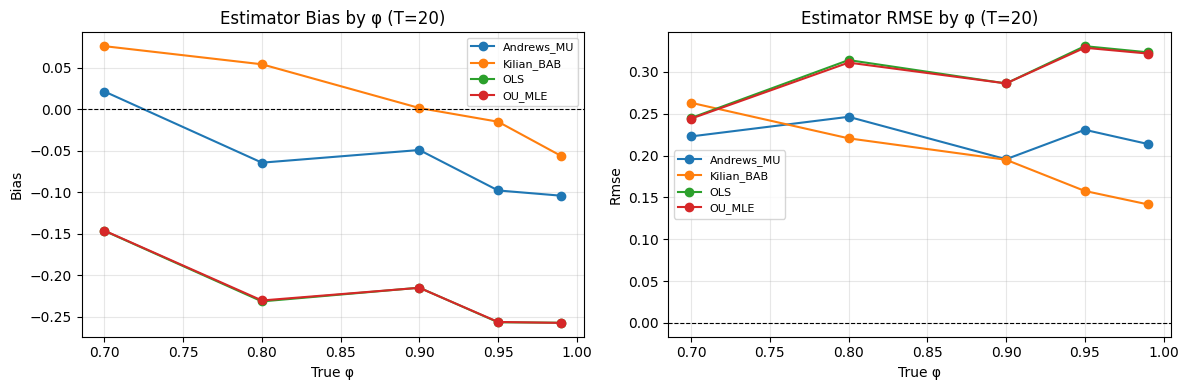

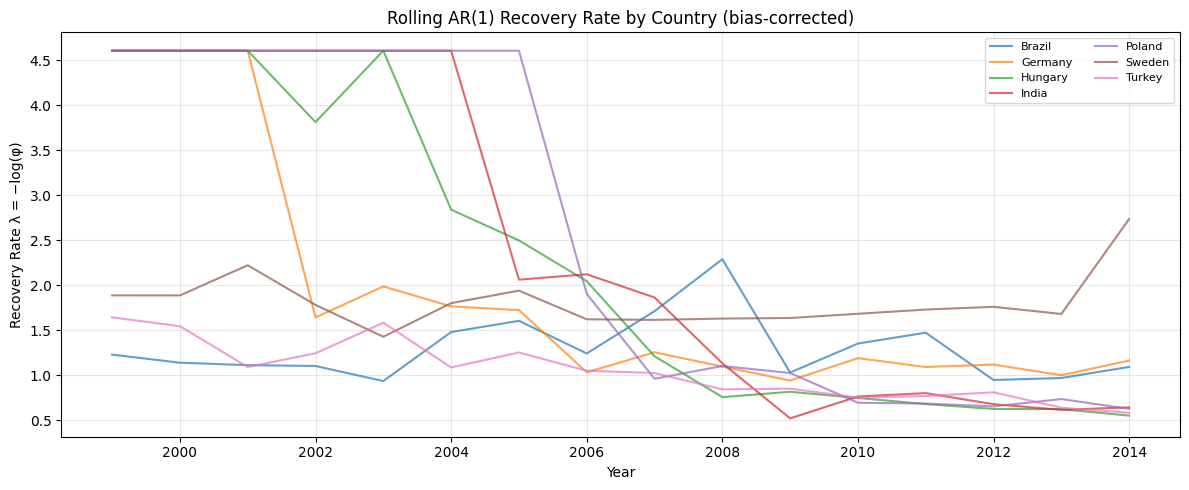

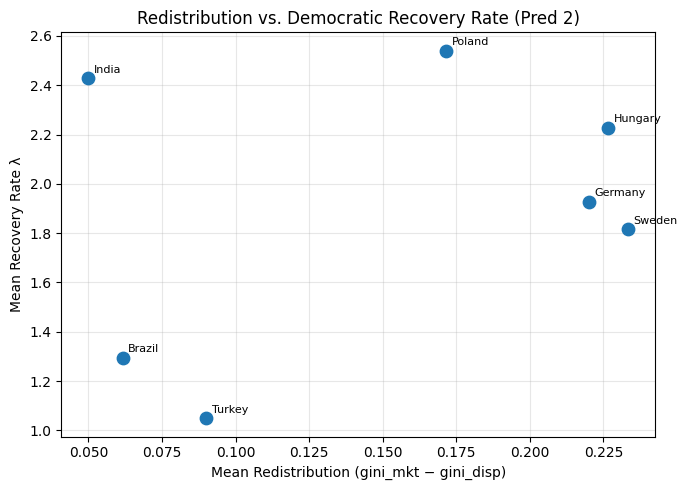

In [12]:
# ── Print pipeline summary ────────────────────────────────────────────────────
print("=" * 60)
print("PIPELINE RESULTS SUMMARY")
print("=" * 60)
print(f"  Estimator selected (Step 0): {estimator_used}")
print(f"  bias_ok:                     {step0.get('bias_ok')}")
print(f"  Max|bias| by estimator:      {step0.get('estimator_max_bias_at_key_phis')}")
print()
print(f"  Recovery panel: {step1.get('n_country_years')} country-years, {step1.get('n_countries')} countries")
print(f"  Mean lambda_bc:  {step1.get('lambda_mean')}  |  Std: {step1.get('lambda_std')}")
print()
print(f"  Step 2 — Pred1 (CSD AUC > 0.55, p < 0.10):")
print(f"    n_cases_with_data={step2.get('n_cases_with_data')}, p_wilcoxon={step2.get('p_wilcoxon')}, auc={step2.get('auc')}")
print(f"    CONFIRMED: {step2.get('prediction1_confirmed')}")
if step2.get('skip_reason'): print(f"    (skipped: {step2['skip_reason']})")
print()
print(f"  Step 3 — Pred2 (redistrib coeff > 0, p < 0.10):")
print(f"    n_obs={step3.get('n_obs')}, coeff={step3.get('coeff_redistribution_lag5')}, p={step3.get('p_redistribution_lag5')}")
print(f"    CONFIRMED: {step3.get('prediction2_confirmed')}")
print()
print(f"  Step 4 — Pred3 (interaction < 0, p < 0.10):")
print(f"    n_onsets={step4.get('n_onsets')}, coeff_interaction={step4.get('coeff_interaction')}, p={step4.get('p_interaction')}")
print(f"    CONFIRMED: {step4.get('prediction3_confirmed')}")
if step4.get('skip_reason'): print(f"    (skipped: {step4['skip_reason']})")
print()
print(f"  Holm-adjusted p-values: {holm.get('p_values_adjusted')}")
print(f"  Holm rejected:          {holm.get('rejected')}")
print("=" * 60)

# ── Plot 1: MC bias comparison ────────────────────────────────────────────────
mc_df = pd.DataFrame(step0["results"])
if not mc_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, metric, title in [
        (axes[0], "bias", "Estimator Bias by φ (T=20)"),
        (axes[1], "rmse", "Estimator RMSE by φ (T=20)"),
    ]:
        for est, grp in mc_df[mc_df["T"] == 20].groupby("estimator"):
            ax.plot(grp["phi_true"], grp[metric], marker="o", label=est)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_xlabel("True φ")
        ax.set_ylabel(metric.capitalize())
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── Plot 2: Recovery rates by country ─────────────────────────────────────────
if not recovery_panel.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    for country, grp in recovery_panel.groupby("country"):
        ax.plot(grp["center_year"], grp["lambda_bc"], alpha=0.7, label=country, linewidth=1.5)
    ax.set_xlabel("Year")
    ax.set_ylabel("Recovery Rate λ = −log(φ)")
    ax.set_title("Rolling AR(1) Recovery Rate by Country (bias-corrected)")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── Plot 3: Redistribution vs mean recovery rate ──────────────────────────────
country_summary = (
    recovery_panel.rename(columns={"center_year": "year"}) if "center_year" in recovery_panel.columns
    else recovery_panel
).groupby("country")["lambda_bc"].mean().reset_index()
redist_mean = redistrib_df.groupby("country")["redistribution"].mean().reset_index()
merged = country_summary.merge(redist_mean, on="country", how="inner")

if not merged.empty:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(merged["redistribution"], merged["lambda_bc"], s=80, zorder=3)
    for _, row in merged.iterrows():
        ax.annotate(row["country"], (row["redistribution"], row["lambda_bc"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Mean Redistribution (gini_mkt − gini_disp)")
    ax.set_ylabel("Mean Recovery Rate λ")
    ax.set_title("Redistribution vs. Democratic Recovery Rate (Pred 2)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()